In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle

In [7]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import models
from PIL import Image

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [9]:
from Custom_scripts import CustomNN

In [10]:
load_dotenv()

True

In [3]:
with open('../pickle_items/class_names.pkl','rb') as f:
    class_names = pickle.load(f)
with open('../pickle_items/valid_labels.pkl','rb') as f:
    valid_labels = pickle.load(f)

In [2]:
# constants 
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
num_classes = 38

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**ACCURACY and LOSS per EPOCH -- while TRAINING and VALIDATION**

In [14]:
# my cnn
with open('../pickle_items/cnn/train_losses_cnn.pkl','rb') as f:
    train_losses_cnn = pickle.load(f)
with open('../pickle_items/cnn/train_accs_cnn.pkl','rb') as f:
    train_accs_cnn = pickle.load(f)
with open('../pickle_items/cnn/valid_accs_cnn.pkl','rb') as f:
    valid_accs_cnn = pickle.load(f)
with open('../pickle_items/cnn/valid_losses_cnn.pkl','rb') as f:
    valid_losses_cnn = pickle.load(f)

# resnet
with open('../pickle_items/resnet/train_losses_resnet.pkl','rb') as f:
    train_losses_resnet = pickle.load(f)
with open('../pickle_items/resnet/train_accs_resnet.pkl','rb') as f:
    train_accs_resnet = pickle.load(f)
with open('../pickle_items/resnet/valid_accs_resnet.pkl','rb') as f:
    valid_accs_resnet = pickle.load(f)
with open('../pickle_items/resnet/valid_losses_resnet.pkl','rb') as f:
    valid_losses_resnet = pickle.load(f)

# effiecientnet_b0
with open('../pickle_items/enet/train_losses_enet.pkl','rb') as f:
    train_losses_enet = pickle.load(f)
with open('../pickle_items/enet/train_accs_enet.pkl','rb') as f:
    train_accs_enet = pickle.load(f)
with open('../pickle_items/enet/valid_accs_enet.pkl','rb') as f:
    valid_accs_enet = pickle.load(f)
with open('../pickle_items/enet/valid_losses_enet.pkl','rb') as f:
    valid_losses_enet = pickle.load(f)

# mobilenet_v02
with open('../pickle_items/mbnet/train_losses_mbnet.pkl','rb') as f:
    train_losses_mbnet = pickle.load(f)
with open('../pickle_items/mbnet/train_accs_mbnet.pkl','rb') as f:
    train_accs_mbnet = pickle.load(f)
with open('../pickle_items/mbnet/valid_accs_mbnet.pkl','rb') as f:
    valid_accs_mbnet = pickle.load(f)
with open('../pickle_items/mbnet/valid_losses_mbnet.pkl','rb') as f:
    valid_losses_mbnet = pickle.load(f)

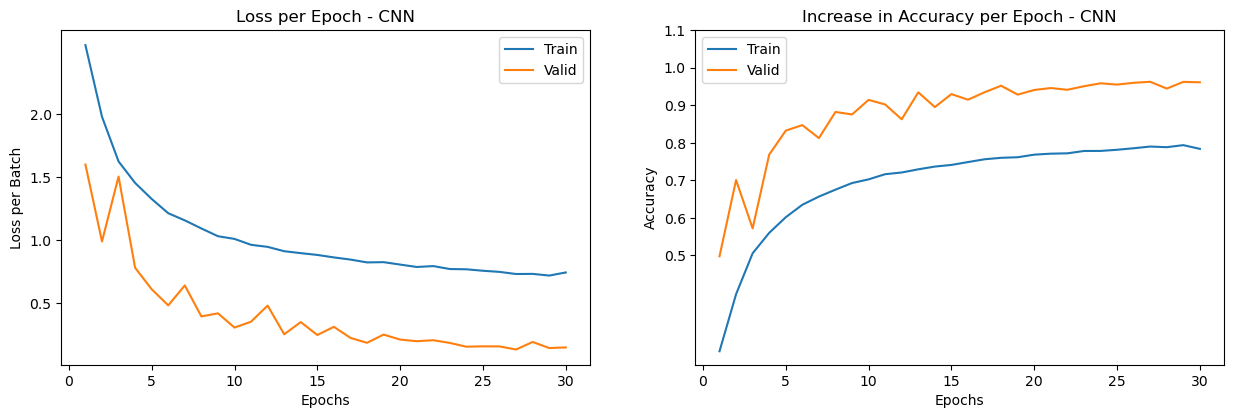

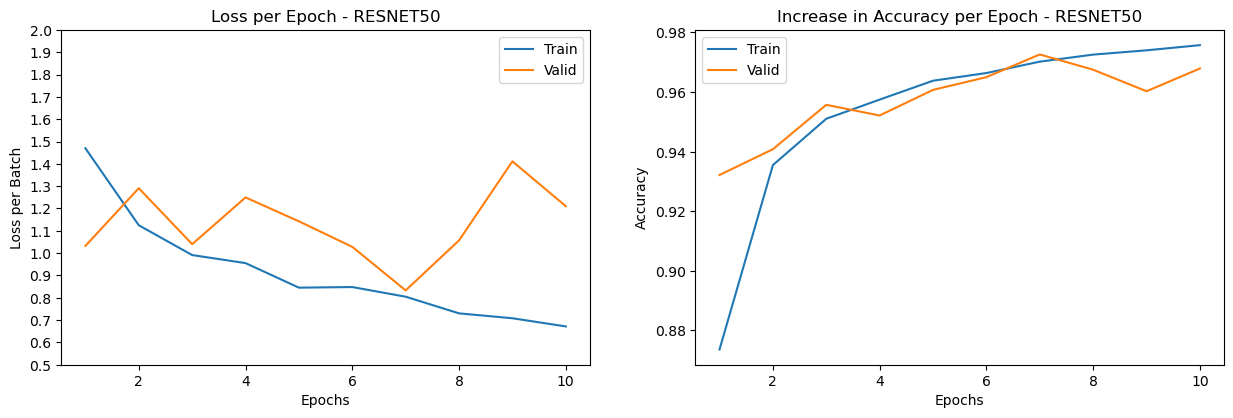

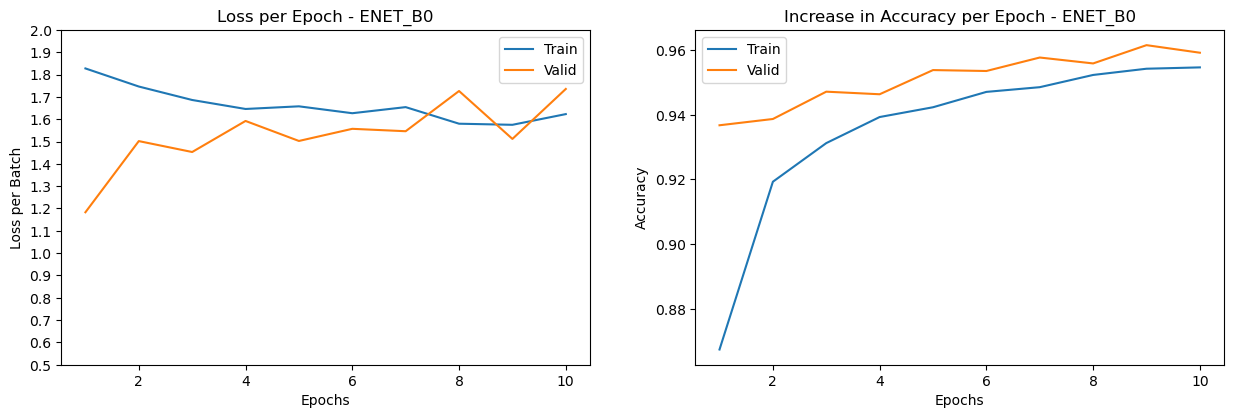

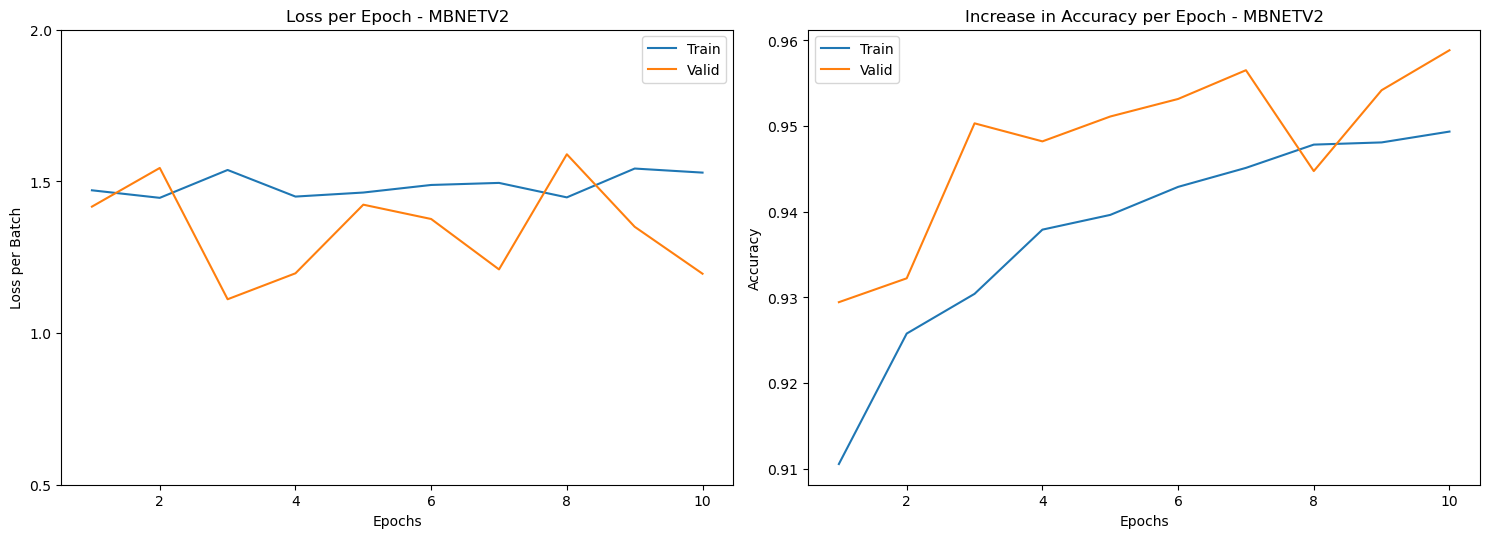

In [105]:
# CNN
plt.figure(figsize=(15,20))
plt.subplot(4,2,1)
plt.plot(range(1,31),train_losses_cnn, label='Train')
plt.plot(range(1,31),valid_losses_cnn, label='Valid')
plt.title('Loss per Epoch - CNN')
plt.yticks(np.arange(0.5, 2.1, 0.5))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')

plt.legend()

plt.subplot(4,2,2)
plt.plot(range(1,31),train_accs_cnn, label='Train')
plt.plot(range(1,31),valid_accs_cnn, label='Valid')
plt.title('Increase in Accuracy per Epoch - CNN')
plt.yticks(np.arange(0.5, 1.1, 0.1))
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# RESNET
plt.figure(figsize=(15,20))
plt.subplot(4,2,3)
plt.plot(range(1,11),train_losses_resnet, label='Train')
plt.plot(range(1,11),valid_losses_resnet, label='Valid')
plt.title('Loss per Epoch - RESNET50')
plt.yticks(np.arange(0.5,2.1,0.1))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(4,2,4)
plt.plot(range(1,11),train_accs_resnet, label='Train')
plt.plot(range(1,11),valid_accs_resnet, label='Valid')
plt.title('Increase in Accuracy per Epoch - RESNET50')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


# EFFIECIENTNET_B0
plt.figure(figsize=(15,20))
plt.subplot(4,2,5)
plt.plot(range(1,11),train_losses_enet, label='Train')
plt.plot(range(1,11),valid_losses_enet, label='Valid')
plt.title('Loss per Epoch - ENET_B0')
plt.yticks(np.arange(0.5,2.1,0.1))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(4,2,6)
plt.plot(range(1,11),train_accs_enet, label='Train')
plt.plot(range(1,11),valid_accs_enet, label='Valid')
plt.title('Increase in Accuracy per Epoch - ENET_B0')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()


# MOBILENET V02
plt.figure(figsize=(15,20))
plt.subplot(4,2,7)
plt.plot(range(1,11),train_losses_mbnet, label='Train')
plt.plot(range(1,11),valid_losses_mbnet, label='Valid')
plt.title('Loss per Epoch - MBNETV2')
plt.yticks(np.arange(0.5, 2.1, 0.5))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(4,2,8)
plt.plot(range(1,11),train_accs_mbnet, label='Train')
plt.plot(range(1,11),valid_accs_mbnet, label='Valid')
plt.title('Increase in Accuracy per Epoch - MBNETV2')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()

**MODEL INSTANCE CREATION**

In [80]:
# CNN
cnn = CustomNN(num_classes=len(class_names))
cnn.load_state_dict(torch.load('../models/model_v05.pth', map_location=device))

<All keys matched successfully>

In [91]:
valid_transform_cnn = transforms.Compose([transforms.Resize(IMAGE_SIZE),transforms.ToTensor()])

In [82]:
# RESNET50

resnet_weights = models.ResNet50_Weights.DEFAULT
resnet = models.resnet50(weights=resnet_weights)

num_features = resnet.fc.in_features
resnet.fc = nn.Sequential(nn.Linear(num_features,num_classes))
resnet.load_state_dict(torch.load('../models/resnet.pkl', map_location=device))

<All keys matched successfully>

In [83]:
# MobileNetV02

mbnet_weights = models.MobileNet_V2_Weights.DEFAULT
mbnet = models.mobilenet_v2(weights=mbnet_weights)

num_features = mbnet.classifier[1].in_features
mbnet.classifier = nn.Sequential(nn.Linear(num_features,num_classes))

mbnet.load_state_dict(torch.load('../models/mbnet.pth', map_location=device))

<All keys matched successfully>

In [88]:
# EffiecientNET_B0

enet_weights = models.EfficientNet_B0_Weights.DEFAULT
enet = models.efficientnet_b0(weights=enet_weights)

num_features = enet.classifier[1].in_features
enet.classifier = nn.Sequential(nn.Linear(num_features,num_classes))

enet.load_state_dict(torch.load('../models/enet.pth', map_location=device))

<All keys matched successfully>

**PREDICTION ON VALIDATION SET**

In [95]:
def validate_predict(model, use_transform):
    model.eval()
    
    valid_dataset = ImageFolder(root="../data/valid",transform=use_transform)
    valid_dataloader = DataLoader(valid_dataset,batch_size=32,shuffle=False)

    pred = []

    with torch.no_grad():
        for images , labels in valid_dataloader:
            y_pred = model(images)
            _,predicted = torch.max(y_pred, axis=1)
            pred.extend(predicted)

    return pred

In [130]:
with open('../pred/pred_cnn.pkl','rb') as f:
    pred_cnn = pickle.load(f)
with open('../pred/pred_resnet.pkl','rb') as f:
    pred_resnet = pickle.load(f)
with open('../pred/pred_enet.pkl','rb') as f:
    pred_enet = pickle.load(f)
with open('../pred/pred_mbnet.pkl','rb') as f:
    pred_mbnet = pickle.load(f)

In [96]:
pred_cnn = validate_predict(cnn, valid_transform_cnn)

In [101]:
pred_resnet = validate_predict(resnet, resnet_weights.transforms())

In [102]:
pred_enet = validate_predict(enet, enet_weights.transforms())

In [108]:
 pred_mbnet =validate_predict(mbnet, valid_transform_cnn)

In [97]:
len(pred_cnn)

17572

In [109]:
accuracy_score(valid_labels,pred_mbnet)

0.9592533576143866

**EVALUATION METRICS**

In [110]:
def eval(model, valid_labels, pred_labels):
    accuracy = accuracy_score(valid_labels, pred_labels)
    precision = precision_score(valid_labels, pred_labels, average='weighted')
    recall = recall_score(valid_labels, pred_labels, average='weighted')
    f1 = f1_score(valid_labels, pred_labels, average='weighted')

    return accuracy, precision, recall, f1

In [111]:
acc_cnn, pre_cnn, recall_cnn, f1_cnn = eval(cnn, valid_labels, pred_cnn)

In [112]:
acc_resnet, pre_resnet, recall_resnet, f1_resnet = eval(resnet, valid_labels, pred_resnet)

In [113]:
acc_enet, pre_enet, recall_enet, f1_enet = eval(enet, valid_labels, pred_enet)

In [114]:
acc_mbnet, pre_mbnet, recall_mbnet, f1_mbnet = eval(mbnet, valid_labels, pred_mbnet)

In [4]:
models = ['CNN','RESNET50','EFFIECIENT_NET_B0','MOBILENET_v02']

In [134]:
accuracy= [acc_cnn,acc_resnet,acc_enet,acc_mbnet]
precision = [pre_cnn,pre_resnet,pre_enet,pre_mbnet]
recall = [recall_cnn, recall_resnet, recall_enet, recall_mbnet]
f1score = [f1_cnn, f1_resnet, f1_enet, f1_mbnet]
models = ['CNN','RESNET50','EFFIECIENT_NET_B0','MOBILENET_v02']
tepochs = [30,10,10,10]

df = pd.DataFrame({'Model':models,
                   'Trained_Epochs':tepochs,
                   'Accuracy':accuracy,
                   'Precision':precision,
                   'Recall': recall,
                  'F1_Score':f1score}, )


df.sort_values('Recall',ascending=False)

,Model,Trained_Epochs,Accuracy,Precision,Recall,F1_Score
1,RESNET50,10,0.965343,0.966463,0.965343,0.965359
0,CNN,30,0.961018,0.962577,0.961018,0.960443
3,MOBILENET_v02,10,0.959253,0.960628,0.959253,0.959103
2,EFFIECIENT_NET_B0,10,0.956977,0.957627,0.956977,0.956557


In [124]:
with open('models_eval_df.pkl','wb') as f:
    pickle.dump(df, f)

In [129]:
with open('pred_cnn.pkl','wb') as f:
    pickle.dump(pred_cnn,f)
with open('pred_resnet.pkl','wb') as f:
    pickle.dump(pred_resnet,f)
with open('pred_enet.pkl','wb') as f:
    pickle.dump(pred_enet,f)
with open('pred_mbnet.pkl','wb') as f:
    pickle.dump(pred_mbnet,f)

**PER CLASS ACCURACY**

In [137]:
def per_clas_accuracy(valid_labels,pred_labels):
    confusion_mat = confusion_matrix(valid_labels, pred_labels)
    per_class_accuracy = confusion_mat.diagonal()/confusion_mat.sum(axis=1)

    return per_class_accuracy

<Axes: >

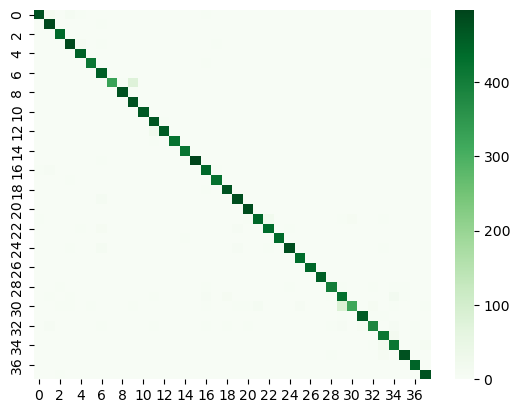

In [90]:
sns.heatmap(confusion_mat, cmap='Greens')

In [138]:
per_class_accuracy_cnn    = per_clas_accuracy(valid_labels, pred_cnn) 
per_class_accuracy_resnet = per_clas_accuracy(valid_labels, pred_resnet) 
per_class_accuracy_enet   = per_clas_accuracy(valid_labels, pred_enet) 
per_class_accuracy_mbnet  = per_clas_accuracy(valid_labels, pred_mbnet) 

In [140]:
df_per_class_accuracy = pd.DataFrame({'Class_Name':class_names,
                                     'Accuracy_CNN':per_class_accuracy_cnn,
                                     'Accuracy_RESNET50':per_class_accuracy_resnet,
                                     'Accuracy_EffecientNet_B0':per_class_accuracy_enet,
                                    'Accuracy_MobileNet_V02':per_class_accuracy_mbnet})
df_per_class_accuracy

,Class_Name,Accuracy_CNN,Accuracy_RESNET50,Accuracy_EffecientNet_B0,Accuracy_MobileNet_V02
0,Apple___Apple_scab,0.942460,0.964286,0.934524,0.946429
1,Apple___Black_rot,0.987928,0.977867,0.991952,0.987928
2,Apple___Cedar_apple_rust,0.997727,0.995455,0.947727,0.988636
3,Apple___healthy,0.972112,0.996016,0.944223,0.984064
4,Blueberry___healthy,0.993392,1.000000,0.984581,0.993392
5,Cherry_(including_sour)___Powdery_mildew,0.980998,0.992874,0.980998,0.997625
6,Cherry_(including_sour)___healthy,1.000000,0.997807,0.989035,0.995614
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.797561,0.868293,0.865854,0.912195
8,Corn_(maize)___Common_rust_,0.993711,0.995807,0.993711,0.991614
9,Corn_(maize)___Northern_Leaf_Blight,0.995807,0.989518,0.947589,0.943396


In [141]:
with open('df_per_class_accuracy.pkl','wb') as f:
    pickle.dump(df_per_class_accuracy, f)

**MIS-CLASSIFIED IMAGES, LABELS**

In [146]:
def count_misclassified(model):
    model.eval()
    misclassified = []
    with torch.no_grad():
        for images, labels in valid_dataloader:
            y_pred = model(images)
            _, predicted = torch.max(y_pred, 1)

            for img, true, pred in zip(images, labels, predicted):
                if true != pred:
                    misclassified.append((img,true.item(),pred.item()))

    return misclassified

In [147]:
misclassified_cnn = count_misclassified(cnn)

In [ ]:
misclassified_resnet = count_misclassified(resnet)

In [ ]:
misclassified_enet = count_misclassified(enet)

In [ ]:
misclassified_mbnet = count_misclassified(mbnet)

In [14]:
misclassified_df = pd.DataFrame({'Models':models,
                                  'Misclassifed':misclassified}
                                )
misclassified_df

,Models,Misclassifed
0,CNN,627
1,RESNET50,610
2,EFFIECIENT_NET_B0,734
3,MOBILENET_v02,656


In [12]:
with open('misclassified_df.pkl','wb') as f:
    pickle.dump(misclassified_df,f)

In [74]:
misclassified[0][0].shape

torch.Size([3, 224, 224])

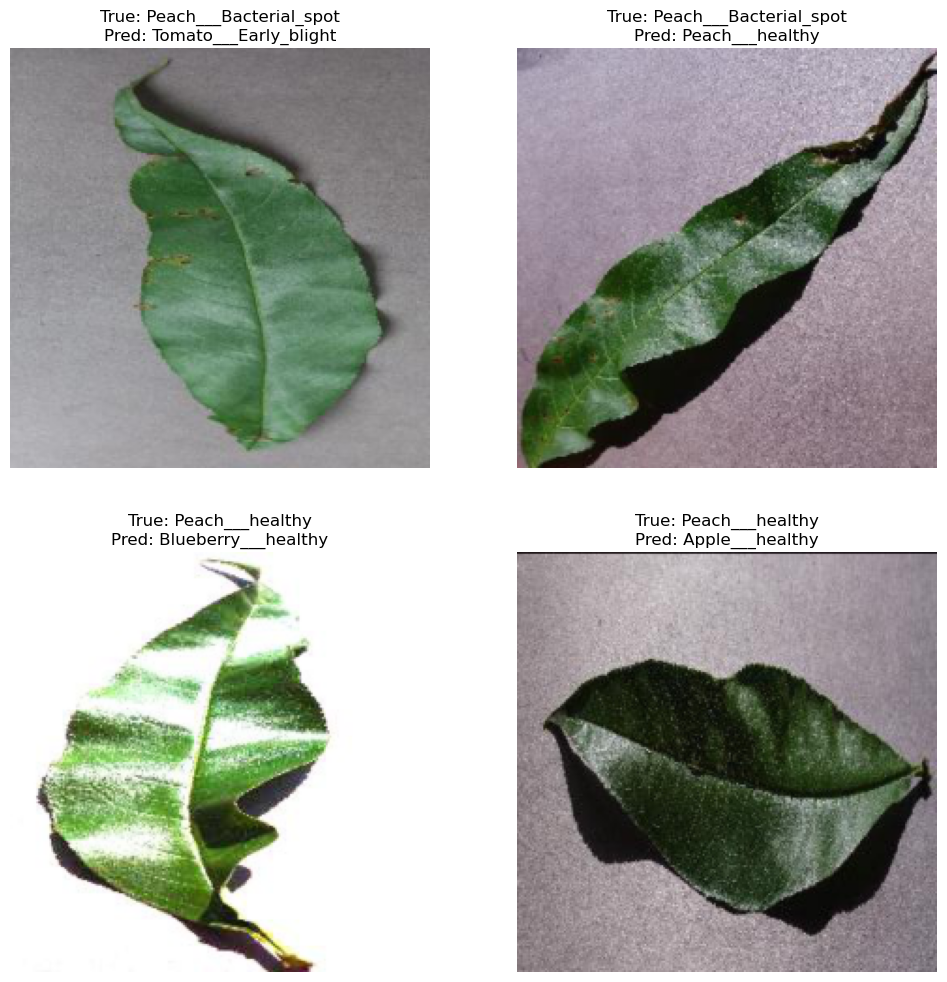

In [78]:
plt.figure(figsize=(12, 12))

for i in range(4):

    img, true, pred = misclassified[i+200]
    plt.subplot(2,2, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    plt.axis("off")

plt.show()

In [92]:
len(train_accs)

30

**TESTING FOR SINGLE IMAGE INPUT**

In [14]:
TEST_DIR = os.getenv('test_folder')

In [49]:
image_name = os.listdir(os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0]))[0]
image_name

'AppleCedarRust1.JPG'

In [37]:
image_path = os.path.join(os.path.join(TEST_DIR, os.listdir(TEST_DIR)[0]), image_name)

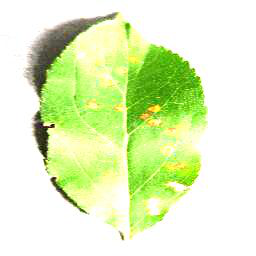

In [39]:
image = Image.open(image_path)
image

In [46]:
transformed_image = test_transform(image)
transformed_image.shape

torch.Size([3, 224, 224])

In [47]:
y_pred = model(transformed_image.unsqueeze(0))

In [48]:
_,predicted = torch.max(y_pred,axis=1)
class_names[predicted]

'Apple___Cedar_apple_rust'